In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import csv
import re
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
SPLIT_SEED = 42
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


!rm -f vast_english_french.txt

!wget -L "https://raw.githubusercontent.com/David-Ojo/UNCC-ECGR-4106/main/Assignment%203/vast_english_french.txt" -O vast_english_french.txt
FILE_NAME = "vast_english_french.txt"

SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_LEN = 10
BATCH_SIZE = 64
EMBED_SIZE = 128
HIDDEN_SIZE = 256
EPOCHS = 200
LEARNING_RATE = 0.001
NUM_LAYERS = 2
DROPOUT = 0.15
TEACHER_FORCING_RATIO = .8

def set_training_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


--2026-07-02 00:34:31--  https://raw.githubusercontent.com/David-Ojo/UNCC-ECGR-4106/main/Assignment%203/vast_english_french.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42659 (42K) [text/plain]
Saving to: ‘vast_english_french.txt’

vast_english_french 100%[===================>]  41.66K  --.-KB/s    in 0.004s  

2026-07-02 00:34:31 (9.23 MB/s) - ‘vast_english_french.txt’ saved [42659/42659]



In [3]:
# Dataset

def normalize_text(s):
    s = s.lower().strip()
    s = re.sub(r"[^a-zA-ZÀ-ÿ0-9?.!,]+", " ", s)
    return s

pairs = []

with open(FILE_NAME, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")

        if len(parts) >= 2:
            eng = normalize_text(parts[0])
            fra = normalize_text(parts[1])

            if len(eng.split()) <= MAX_LEN and len(fra.split()) <= MAX_LEN:
                pairs.append((eng, fra))

print("Total sentence pairs:", len(pairs))

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SPLIT_SEED,
    shuffle=True
)

print("Train size:", len(train_pairs))
print("Validation size:", len(val_pairs))


#Vocab Section


def build_vocab(sentences):
    vocab = {
        PAD_TOKEN: 0,
        SOS_TOKEN: 1,
        EOS_TOKEN: 2,
        UNK_TOKEN: 3
    }

    for sentence in sentences:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

eng_vocab = build_vocab([p[0] for p in train_pairs])
fra_vocab = build_vocab([p[1] for p in train_pairs])

eng_idx_to_word = {idx: word for word, idx in eng_vocab.items()}
fra_idx_to_word = {idx: word for word, idx in fra_vocab.items()}

PAD_IDX = fra_vocab[PAD_TOKEN]

print("English vocab size:", len(eng_vocab))
print("French vocab size:", len(fra_vocab))

#Dataset - Class

def sentence_to_indices(sentence, vocab):
    indices = [vocab.get(word, vocab[UNK_TOKEN]) for word in sentence.split()]
    indices = [vocab[SOS_TOKEN]] + indices + [vocab[EOS_TOKEN]]

    if len(indices) < MAX_LEN + 2:
        indices += [vocab[PAD_TOKEN]] * ((MAX_LEN + 2) - len(indices))
    else:
        indices = indices[:MAX_LEN + 2]

    return torch.tensor(indices, dtype=torch.long)

class TranslationDataset(Dataset):
    def __init__(self, pairs, eng_vocab, fra_vocab):
        self.pairs = pairs
        self.eng_vocab = eng_vocab
        self.fra_vocab = fra_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng, fra = self.pairs[idx]

        src = sentence_to_indices(eng, self.eng_vocab)
        tgt = sentence_to_indices(fra, self.fra_vocab)

        return src, tgt

train_dataset = TranslationDataset(train_pairs, eng_vocab, fra_vocab)
val_dataset = TranslationDataset(val_pairs, eng_vocab, fra_vocab)


# Loop init
TRAIN_SEED = 0
set_training_seed(TRAIN_SEED)
g = torch.Generator()
g.manual_seed(TRAIN_SEED)
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,generator=g)
valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Total sentence pairs: 515
Train size: 412
Validation size: 103
English vocab size: 841
French vocab size: 935


In [4]:
#Model 1




class EncoderGRU(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size,dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size,num_layers=NUM_LAYERS,dropout=DROPOUT, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        src_len = encoder_outputs.shape[1]

        hidden = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

class DecoderGRU(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size,dropout, attention):
        super().__init__()

        self.output_dim = output_size
        self.attention = attention

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size + hidden_size, hidden_size,num_layers=NUM_LAYERS,dropout=DROPOUT, batch_first=True)
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
      # input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))

        attn_weights = self.attention(hidden, encoder_outputs)

        context = torch.bmm( attn_weights.unsqueeze(1), encoder_outputs)

        gru_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(gru_input, hidden)
        prediction = self.fc(
            torch.cat(
                (output.squeeze(1), context.squeeze(1)),
                dim=1
            )
        )
        return prediction, hidden, attn_weights


class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size).to(device)

        encoder_outputs, hidden = self.encoder(src)

        decoder_input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, attn = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t - 1, :] = output

            teacher_force = random.random() < TEACHER_FORCING_RATIO

            top1 = output.argmax(1).unsqueeze(1)

            if teacher_force:
                decoder_input = tgt[:, t].unsqueeze(1)
            else:
                decoder_input = top1
        return outputs

    # Optimizer
attention = Attention(HIDDEN_SIZE)
encoder = EncoderGRU(len(eng_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT)
decoder = DecoderGRU(len(fra_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT, attention)

model = Seq2SeqGRU(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor= 0.1,
    patience=10
)

print(next(model.parameters()).device)

# Training

def train_one_epoch(model, trainloader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for src, tgt in trainloader:
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        outputs = model(src, tgt)

        # outputs: [batch, tgt_len-1, vocab_size]
        # target:  [batch, tgt_len-1]
        outputs = outputs.reshape(-1, outputs.shape[-1])
        target = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(trainloader)


def evaluate_loss(model, valloader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for src, tgt in valloader:
            src = src.to(device)
            tgt = tgt.to(device)

            outputs = model(src, tgt)

            outputs = outputs.reshape(-1, outputs.shape[-1])
            target = tgt[:, 1:].reshape(-1)

            loss = criterion(outputs, target)

            total_loss += loss.item()

    return total_loss / len(valloader)


train_losses = []
val_losses = []
best_val_loss = float("inf")
patience = 50
bad_epochs = 0

training_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, trainloader, optimizer, criterion)
    val_loss = evaluate_loss(model, valloader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), "best_translation_gru.pth")
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        break

    epoch_time = time.time() - epoch_start
    scheduler.step(val_loss)
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Time: {epoch_time:.2f}s"
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

total_training_time = time.time() - training_start
print(f"Total Training Time: {total_training_time:.2f} seconds")


cuda:0
Epoch [1/200] Train Loss: 6.4401 Val Loss: 6.0808 Time: 1.21sLR: 0.001000
Epoch [2/200] Train Loss: 5.5737 Val Loss: 5.6918 Time: 0.28sLR: 0.001000
Epoch [3/200] Train Loss: 5.3018 Val Loss: 5.5995 Time: 0.27sLR: 0.001000
Epoch [4/200] Train Loss: 5.0645 Val Loss: 5.4958 Time: 0.28sLR: 0.001000
Epoch [5/200] Train Loss: 4.8548 Val Loss: 5.3485 Time: 0.28sLR: 0.001000
Epoch [6/200] Train Loss: 4.6196 Val Loss: 5.1844 Time: 0.27sLR: 0.001000
Epoch [7/200] Train Loss: 4.3499 Val Loss: 5.0183 Time: 0.28sLR: 0.001000
Epoch [8/200] Train Loss: 4.0747 Val Loss: 4.9015 Time: 0.29sLR: 0.001000
Epoch [9/200] Train Loss: 3.8504 Val Loss: 4.7779 Time: 0.27sLR: 0.001000
Epoch [10/200] Train Loss: 3.6259 Val Loss: 4.7378 Time: 0.27sLR: 0.001000
Epoch [11/200] Train Loss: 3.3904 Val Loss: 4.6807 Time: 0.31sLR: 0.001000
Epoch [12/200] Train Loss: 3.1916 Val Loss: 4.6003 Time: 0.31sLR: 0.001000
Epoch [13/200] Train Loss: 2.9875 Val Loss: 4.6083 Time: 0.26sLR: 0.001000
Epoch [14/200] Train Loss: 

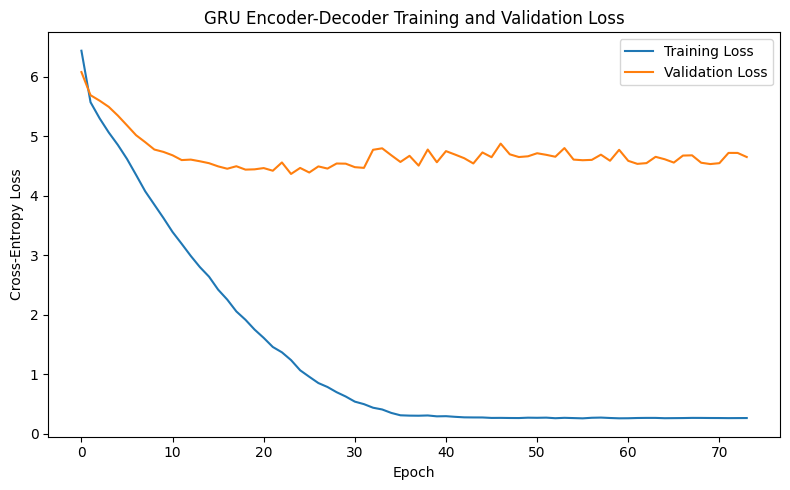

In [5]:

# Training Results

output_dir = "problem2_attention_results"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("GRU Encoder-Decoder Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_curves.png"))
#plt.show()

#Eval/validation


def indices_to_sentence(indices, idx_to_word):
    words = []

    for idx in indices:
        word = idx_to_word.get(int(idx), UNK_TOKEN)

        if word == EOS_TOKEN:
            break

        if word not in [SOS_TOKEN, PAD_TOKEN]:
            words.append(word)

    return " ".join(words)



#inference
def translate_sentence(model, sentence,sample_id=0, max_len=MAX_LEN + 2, return_attention=False):
    model.eval()

    src = sentence_to_indices(sentence, eng_vocab).unsqueeze(0).to(device)

    predicted_indices = []
    attention_map = []

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)

        decoder_input = torch.tensor([[fra_vocab[SOS_TOKEN]]], device=device)

        for _ in range(max_len):
            output, hidden, attn = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs
            )

            predicted_token = output.argmax(1).item()

            if predicted_token == fra_vocab[EOS_TOKEN]:
                break

            predicted_indices.append(predicted_token)
            attention_map.append(attn.squeeze(0).cpu().numpy())

            decoder_input = torch.tensor([[predicted_token]], device=device)

    sentence_out = indices_to_sentence(predicted_indices, fra_idx_to_word)

    if sample_id < 2:
        plt.figure(figsize=(10,8))
        plt.imshow(attention_map, cmap="viridis", aspect="auto")
        plt.xlabel("Input Words")
        plt.ylabel("Output Words")
        plt.colorbar()
        plt.title("Attention Alignment")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"attention_map_{sample_id}.png"))
        plt.close()



    if return_attention:
        return sentence_out, attention_map

    return sentence_out


def compute_exact_match_and_bleu(model, val_pairs):
    exact_matches = 0
    bleu_scores = []

    smoothing = SmoothingFunction().method1

    results = []

    for i, (eng, fra) in enumerate(val_pairs):
        predicted = translate_sentence(model, eng, sample_id=i)

        reference_tokens = fra.split()
        predicted_tokens = predicted.split()

        exact_match = predicted.strip() == fra.strip()

        if exact_match:
            exact_matches += 1

        bleu = sentence_bleu(
            [reference_tokens],
            predicted_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothing
        )

        bleu_scores.append(bleu)

        results.append({
            "English": eng,
            "Target French": fra,
            "Predicted French": predicted,
            "Exact Match": exact_match,
            "BLEU-4": bleu
        })

    exact_match_accuracy = 100 * exact_matches / len(val_pairs)
    average_bleu = sum(bleu_scores) / len(bleu_scores)

    return exact_match_accuracy, average_bleu, results

In [6]:
# Showing it works
TRAIN_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
              13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
              24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
              36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
              49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
              61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
               73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
              86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100
           8 ]

sweep_results = []

for train_seed in TRAIN_SEEDS:

    print(f"\nRunning Train Seed {train_seed}")

    set_training_seed(train_seed)

    g = torch.Generator()
    g.manual_seed(train_seed)

    trainloader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=g
    )

    valloader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Rebuild model every seed
    attention = Attention(HIDDEN_SIZE)

    encoder = EncoderGRU(
        len(eng_vocab),
        EMBED_SIZE,
        HIDDEN_SIZE,
        DROPOUT
    )

    decoder = DecoderGRU(
        len(fra_vocab),
        EMBED_SIZE,
        HIDDEN_SIZE,
        DROPOUT,
        attention
    )

    model = Seq2SeqGRU(encoder, decoder).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=10
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    bad_epochs = 0
    patience = 50

    checkpoint_name = f"best_attention_gru_seed_{train_seed}.pth"

    training_start = time.time()

    for epoch in range(EPOCHS):

        epoch_start = time.time()

        train_loss = train_one_epoch(
            model,
            trainloader,
            optimizer,
            criterion
        )

        val_loss = evaluate_loss(
            model,
            valloader,
            criterion
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
            torch.save(model.state_dict(), checkpoint_name)
        else:
            bad_epochs += 1

        scheduler.step(val_loss)

        epoch_time = time.time() - epoch_start

        print(
            f"Seed {train_seed} "
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Time: {epoch_time:.2f}s "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    total_training_time = time.time() - training_start

    # Load best model before final validation metrics
    model.load_state_dict(torch.load(checkpoint_name))
    model.eval()

    exact_acc, avg_bleu, validation_results = compute_exact_match_and_bleu(
    model,
    val_pairs
    )

    sweep_results.append({
        "train_seed": train_seed,
        "best_val_loss": best_val_loss,
        "exact_acc": exact_acc,
        "bleu": avg_bleu,
        "training_time": total_training_time,
        "train_losses": train_losses,
        "val_losses": val_losses
    })

    print(
        f"\nSeed {train_seed} Final Results: "
        f"Best Val Loss: {best_val_loss:.4f}, "
        f"Exact Acc: {exact_acc:.2f}%, "
        f"BLEU-4: {avg_bleu:.4f}, "
        f"Time: {total_training_time:.2f}s"
    )

    print("\nSeed Sweep Results")
    print("=" * 60)


    print("\nSeed Sweep Results")
    print("=" * 60)

    for result in sweep_results:
        print(
            f"Seed {result['train_seed']} | "
            f"Best Val Loss: {result['best_val_loss']:.4f} | "
            f"Exact Acc: {result['exact_acc']:.2f}% | "
            f"BLEU-4: {result['bleu']:.4f} | "
            f"Time: {result['training_time']:.2f}s"
        )

    best_run = max(sweep_results, key=lambda x: x["bleu"])

    print("\nBest Run by BLEU-4:")
    print(
        f"Seed {best_run['train_seed']} | "
        f"Best Val Loss: {best_run['best_val_loss']:.4f} | "
        f"Exact Acc: {best_run['exact_acc']:.2f}% | "
        f"BLEU-4: {best_run['bleu']:.4f} | "
        f"Time: {best_run['training_time']:.2f}s"
    )

    best_seed = best_run["train_seed"]

best_run = max(sweep_results, key=lambda x: x["bleu"])
best_seed = best_run["train_seed"]

output_dir = "problem2_attention_results"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(best_run["train_losses"], label="Training Loss")
plt.plot(best_run["val_losses"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Best Attention GRU Loss Curves - Seed {best_seed}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"best_attention_loss_seed_{best_seed}.png"))
plt.close()

attention = Attention(HIDDEN_SIZE)
encoder = EncoderGRU(len(eng_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT)
decoder = DecoderGRU(len(fra_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT, attention)

best_model = Seq2SeqGRU(encoder, decoder).to(device)

best_model.load_state_dict(
    torch.load(f"best_attention_gru_seed_{best_seed}.pth")
)

best_model.eval()

exact_acc, avg_bleu, validation_results = compute_exact_match_and_bleu(
    best_model,
    val_pairs
)

attention = Attention(HIDDEN_SIZE)

encoder = EncoderGRU(
    len(eng_vocab),
    EMBED_SIZE,
    HIDDEN_SIZE,
    DROPOUT
)

decoder = DecoderGRU(
    len(fra_vocab),
    EMBED_SIZE,
    HIDDEN_SIZE,
    DROPOUT,
    attention
)

best_model = Seq2SeqGRU(encoder, decoder).to(device)

best_model.load_state_dict(
    torch.load(f"best_attention_gru_seed_{best_seed}.pth")
)

best_model.eval()

print(f"Validation Exact Match Accuracy: {exact_acc:.2f}%")
print(f"Validation BLEU-4 Score: {avg_bleu:.4f}")
print(f"Total Training Time: {total_training_time:.2f} seconds")

with open(os.path.join(output_dir, "summary.txt"), "w", encoding="utf-8") as f:
    f.write("Problem 1: GRU Encoder-Decoder Baseline\n")
    f.write("=" * 50 + "\n")
    f.write(f"Training size: {len(train_pairs)}\n")
    f.write(f"Validation size: {len(val_pairs)}\n")
    f.write(f"English vocab size: {len(eng_vocab)}\n")
    f.write(f"French vocab size: {len(fra_vocab)}\n")
    f.write(f"Embedding size: {EMBED_SIZE}\n")
    f.write(f"Hidden size: {HIDDEN_SIZE}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Learning rate: {LEARNING_RATE}\n")
    f.write(f"Final Training Loss: {train_losses[-1]:.4f}\n")
    f.write(f"Final Validation Loss: {val_losses[-1]:.4f}\n")
    f.write(f"Validation Exact Match Accuracy: {exact_acc:.2f}%\n")
    f.write(f"Validation BLEU-4 Score: {avg_bleu:.4f}\n")
    f.write(f"Total Training Time: {total_training_time:.2f} seconds\n")

    sample_results = validation_results[:5]

with open(os.path.join(output_dir, "qualitative_samples.txt"), "w", encoding="utf-8") as f:
    for i, result in enumerate(sample_results, start=1):
        print(f"\nSample {i}")
        print("English:", result["English"])
        print("Target French:", result["Target French"])
        print("Predicted French:", result["Predicted French"])
        print("Exact Match:", result["Exact Match"])
        print(f"BLEU-4: {result['BLEU-4']:.4f}")

        f.write(f"Sample {i}\n")
        f.write(f"English: {result['English']}\n")
        f.write(f"Target French: {result['Target French']}\n")
        f.write(f"Predicted French: {result['Predicted French']}\n")
        f.write(f"Exact Match: {result['Exact Match']}\n")
        f.write(f"BLEU-4: {result['BLEU-4']:.4f}\n")
        f.write("-" * 50 + "\n")

with open(os.path.join(output_dir, "validation_predictions.csv"), "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "English",
            "Target French",
            "Predicted French",
            "Exact Match",
            "BLEU-4"
        ]
    )

    writer.writeheader()
    writer.writerows(validation_results)



Running Train Seed 8
Seed 8 Epoch [1/200] Train Loss: 6.4381 Val Loss: 5.9259 Time: 0.29s LR: 0.001000
Seed 8 Epoch [2/200] Train Loss: 5.5983 Val Loss: 5.5818 Time: 0.28s LR: 0.001000
Seed 8 Epoch [3/200] Train Loss: 5.3102 Val Loss: 5.5166 Time: 0.27s LR: 0.001000
Seed 8 Epoch [4/200] Train Loss: 5.0607 Val Loss: 5.3999 Time: 0.28s LR: 0.001000
Seed 8 Epoch [5/200] Train Loss: 4.8356 Val Loss: 5.2925 Time: 0.29s LR: 0.001000
Seed 8 Epoch [6/200] Train Loss: 4.5739 Val Loss: 5.1516 Time: 0.28s LR: 0.001000
Seed 8 Epoch [7/200] Train Loss: 4.3292 Val Loss: 5.0172 Time: 0.28s LR: 0.001000
Seed 8 Epoch [8/200] Train Loss: 4.0766 Val Loss: 4.9240 Time: 0.27s LR: 0.001000
Seed 8 Epoch [9/200] Train Loss: 3.8543 Val Loss: 4.8668 Time: 0.28s LR: 0.001000
Seed 8 Epoch [10/200] Train Loss: 3.6504 Val Loss: 4.7987 Time: 0.28s LR: 0.001000
Seed 8 Epoch [11/200] Train Loss: 3.4636 Val Loss: 4.7438 Time: 0.33s LR: 0.001000
Seed 8 Epoch [12/200] Train Loss: 3.2708 Val Loss: 4.7121 Time: 0.31s LR: 

KeyboardInterrupt: 